In [173]:
from pyrokinetics import Pyro, PyroScan, PyroHypercube
import os
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

In [174]:
from dotenv import load_dotenv
from pyrokinetics import Pyro
from general_analysis import mode_classification as mc

load_dotenv(Path.cwd().parent / "local.env")
data_root = Path(os.environ["GK_DATA_ROOT"])

In [175]:
print(data_root)

/pitagora_scratch/userexternal/fwatts00/Gyrokinetic_Simulations


In [176]:
zenodo = Path("/pitagora_scratch/userexternal/fwatts00/zenodo/")

In [177]:
MTM_latin_base = zenodo / "linear" / "cgyro" / "coll" / "nue030_sh07" / "n25" / "input.cgyro"
pyro_MTM = Pyro(gk_file = MTM_latin_base)

In [178]:
pyro_MTM.load_gk_output()

In [179]:
theta_limits = (50*-np.pi, 50*np.pi)   # zoom around theta = 0
phi_MTM = np.real(pyro_MTM.gk_output["phi"].isel(time=-1, ky=0, kx=0))
apar_MTM = np.real(pyro_MTM.gk_output["apar"].isel(time=-1, ky=0, kx=0))

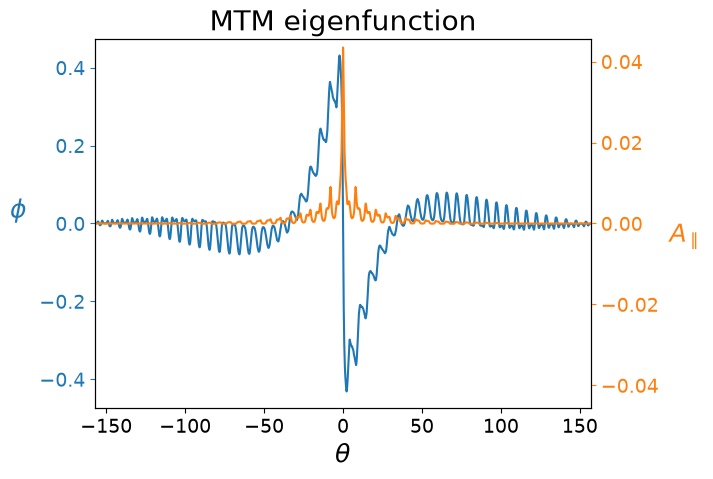

In [180]:
# Edit theta_limits in the cell above, then rerun that cell and this one.
fig, ax_phi = plt.subplots()
ax_apar = ax_phi.twinx()
phi_MTM.plot(ax=ax_phi, color="C0", label=r"$\phi$")
apar_MTM.plot(ax=ax_apar, color="C1", label=r"$A_\parallel$")
apar_limit = max(-ax_apar.get_ylim()[0], ax_apar.get_ylim()[1])
ax_apar.set(ylim=(-apar_limit, apar_limit), ylabel=r"$A_\parallel$", title="")
ax_phi.set(xlim=theta_limits, xlabel=r"$\theta$", ylabel=r"$\phi$", title="MTM eigenfunction")
ax_phi.tick_params(axis="both", labelsize=14)
ax_phi.tick_params(axis="y", colors="C0")
ax_apar.tick_params(axis="y", colors="C1", labelsize=14)
ax_phi.set_xlabel(r"$\theta$", rotation=0, fontsize=18)
ax_phi.set_ylabel(r"$\phi$", rotation=0, labelpad=15, color="C0", fontsize=18)
ax_apar.set_ylabel(r"$A_\parallel$", rotation=0, labelpad=20, color="C1", fontsize=18)
ax_phi.set_title("MTM eigenfunction", fontsize=20)
plt.show()

In [181]:
repo_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir())
output_dir = repo_root / "Plots" / "Eigenfunctions"
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "MTM_eigenfunction.png", dpi=300, bbox_inches="tight")

In [182]:
data_root
KBM_latin_base = data_root / "GS2" / "Runs" / "scan_shat" / "S1_3" / "parameter_scan_GS2"
KBM_latin_netcdf = KBM_latin_base / "pyroscan.nc"
KBM_latin_json = KBM_latin_base / "pyroscan.json"
pyro_KBM = PyroScan(pyroscan_json = KBM_latin_json,load_base_pyro=True)

/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1792: UserWarning: Explicitly set value of beta (0.09 beta_ref_ee_B0_pyroscan_base0005) is inconsistent with value from physical reference values (0.09609377161346086 beta_ref_ee_B0_pyroscan_base0005)
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:944: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0005'. 
  warnings.warn(


In [183]:
pyro_KBM.load_gk_output(netcdf_file = KBM_latin_netcdf)

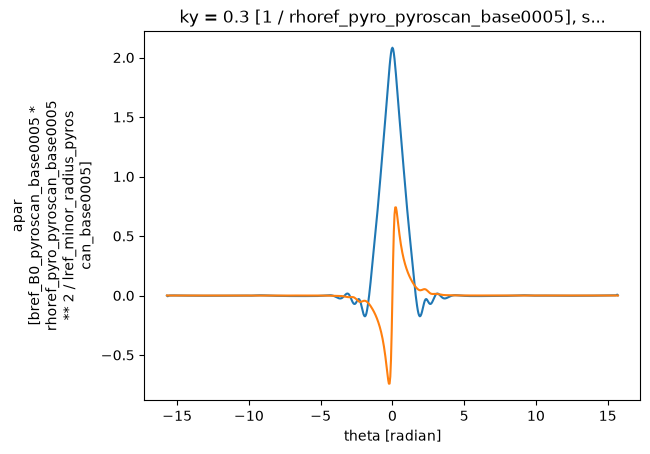

In [184]:
np.real(pyro_KBM.gk_output["phi"].isel(shat = 3).isel(ky=3)).plot()
np.real(pyro_KBM.gk_output["apar"].isel(shat = 3).isel(ky=3)).plot()

In [185]:
theta_limits = (2*-np.pi, 2*np.pi)   # zoom around theta = 0
phi_KBM = np.real(pyro_KBM.gk_output["phi"].isel(shat = 3).isel(ky=3))
apar_KBM = np.real(pyro_KBM.gk_output["apar"].isel(shat = 3).isel(ky=3))

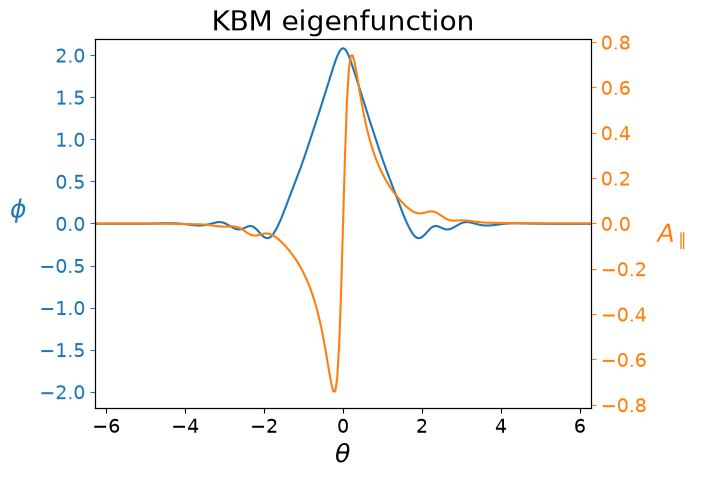

In [186]:
# Edit theta_limits in the cell above, then rerun that cell and this one.
fig, ax_phi = plt.subplots()
ax_apar = ax_phi.twinx()
phi_KBM.plot(ax=ax_phi, color="C0", label=r"$\phi$")
apar_KBM.plot(ax=ax_apar, color="C1", label=r"$A_\parallel$")
apar_limit = max(-ax_apar.get_ylim()[0], ax_apar.get_ylim()[1])
phi_limit = max(-ax_phi.get_ylim()[0], ax_phi.get_ylim()[1])
ax_apar.set(ylim=(-apar_limit, apar_limit), ylabel=r"$A_\parallel$", title="")
ax_phi.set(xlim=theta_limits,ylim=(-phi_limit, phi_limit), xlabel=r"$\theta$", ylabel=r"$\phi$", title="KBM eigenfunction")
ax_phi.tick_params(axis="both", labelsize=14)
ax_phi.tick_params(axis="y", colors="C0")
ax_apar.tick_params(axis="y", colors="C1", labelsize=14)
ax_phi.set_xlabel(r"$\theta$", rotation=0, fontsize=18)
ax_phi.set_ylabel(r"$\phi$", rotation=0, labelpad=15, color="C0", fontsize=18)
ax_apar.set_ylabel(r"$A_\parallel$", rotation=0, labelpad=20, color="C1", fontsize=18)
ax_phi.set_title("KBM eigenfunction", fontsize=20)
plt.show()

In [187]:
repo_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir())
output_dir = repo_root / "Plots" / "Eigenfunctions"
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "KBM_eigenfunction.png", dpi=300, bbox_inches="tight")